In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from brokenaxes import brokenaxes
plt.rcParams['text.usetex'] = False

sns.set_theme(style="whitegrid") # 设置一个美观的背景主题
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df_risk_scores = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')

df_info = pd.read_excel('./Data/S&P500_List_2025.xlsx')
df_info = df_info[['Symbol', 'GICS_Sector']]
df_info = df_info[df_info['Symbol'].isin(df_risk_scores['ticker'])]

df_merged = pd.merge(df_risk_scores, df_info,
                     how='left',
                     left_on='ticker',
                     right_on='Symbol')

avg_risk_by_sector = df_merged.groupby(['year', 'GICS_Sector'])['risk_score'].median().reset_index()

In [69]:
year_mean = df_merged.groupby(['year'])['risk_score'].median().reset_index()['risk_score']
year_max = df_merged.groupby(['year'])['risk_score'].max().reset_index()['risk_score']
year_min = df_merged.groupby(['year'])['risk_score'].min().reset_index()['risk_score']
year = range(2020, 2024)

# 使用手动调整的空格来确保完美对齐
statement = ['Max: 193, Min: 1, Mean: 49',
             'Max: 195, Min: 1, Mean: 46',
             'Max:   97, Min: 2, Mean: 32',
             'Max:   72, Min: 1, Mean: 15']

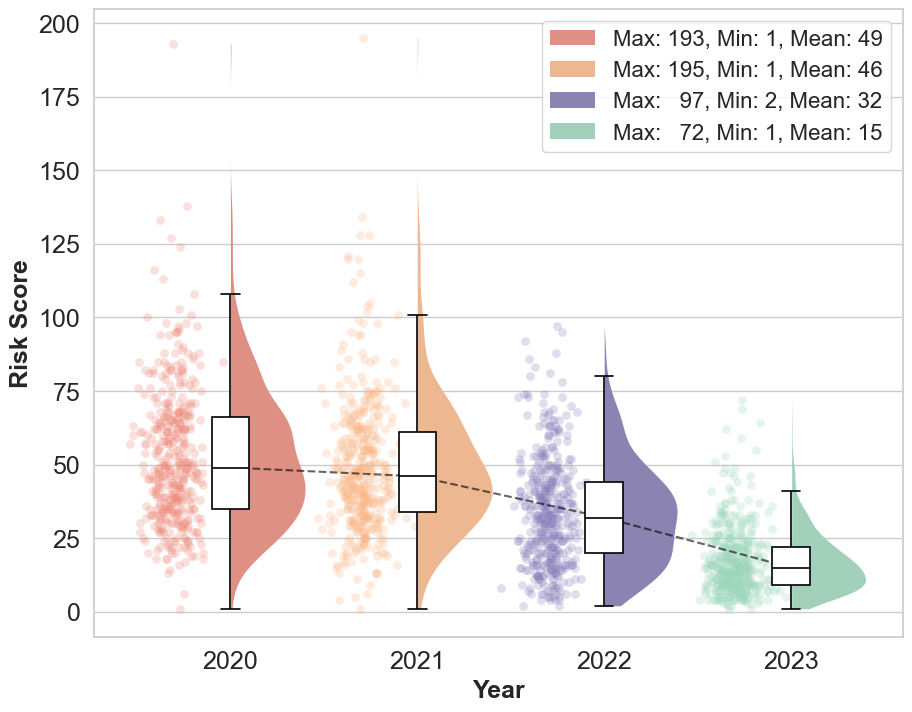

In [100]:
# 1. 左图
fig_1, axes_1 = plt.subplots(figsize=(9, 7))

cats = df_merged['year'].unique().tolist()
violin_palette = ["#EE8575", "#FBB482", "#867bb9", "#9cd7bc"]

vp = sns.violinplot(
    x="year", y="risk_score", data=df_merged,
    palette=violin_palette, ax=axes_1, cut=0, inner=None, alpha=1, linewidth=0, width=0.8, edgecolor='black',
)

for index, violin in enumerate(vp.collections):
    path = violin.get_paths()[0]
    verts = path.vertices
    mid_x = np.median(verts[:, 0])
    verts[:,0] = np.where(verts[:,0] < mid_x, mid_x, verts[:,0])
    if index == 2:
        verts[:, 0] += -0.01
    if index == 3:
        verts[:, 0] += -0.001

# 1.2 添加箱线图
sns.boxplot(
    x="year", y="risk_score", data=df_merged,
    width=0.2, ax=axes_1, showcaps=True,
    capprops={"zorder":4, "linewidth":1.2, "color":"black"},
    boxprops={"zorder":4, "linewidth":1.2, "facecolor":"white", "edgecolor":"black"},
    whiskerprops={"linewidth":1.2, "color":"black", "zorder":4}, 
    medianprops={"linewidth":1.2, "color":"black", "zorder":4},
    showfliers=False, color="white", zorder=4
)

# 1.3 添加散点图
offset = 0.3          # 散点整体向左移动的量，≈小提琴宽度的一半
jitter = 0.08         # 额外随机抖动，避免画成一条竖线

for i, cat in enumerate(cats):
    y_vals = df_merged.loc[df_merged["year"] == cat, "risk_score"]
    # 以类别索引 (i) 为中心，整体向左 offset，再加一点随机 jitter
    x_vals = np.random.normal(loc=i - offset, scale=jitter, size=len(y_vals))
    axes_1.scatter(
        x_vals, y_vals,
        s=40, alpha=0.25, color=violin_palette[i], zorder=1, linewidth=0
    )

# 1.4 添加均值线
mean_scores = df_merged.groupby("year")["risk_score"].median().values
axes_1.plot(range(len(mean_scores)), mean_scores,
         color="#00000099",           # 线条颜色
         marker='o',            # 标记点样式
         markersize=8,         # 标记点大小
         linestyle='dashed',       # 线条样式
         linewidth=1.5,           # 线条宽度
         label='年度均值',
         zorder=3)

axes_1.set_xlabel("")
axes_1.set_ylabel("")
axes_1.set_xticks(range(len(cats)))
# axes_1.set_yticklabels([0, 20, 40, 60, 80, 100, 120, '200'], fontsize=20, zorder=4)
axes_1.tick_params(axis='x', labelsize=18)
axes_1.tick_params(axis='y', labelsize=18)
# axes_1.set_title('Annual Distribution of Risk-Impact Scores', fontsize=20, fontweight='bold')

axes_1.legend(statement, fontsize=16)
fig_1.tight_layout()
axes_1.set_xlabel('Year', fontsize=18, weight='bold')
axes_1.set_ylabel('Risk Score', fontsize=18, weight='bold')
plt.savefig('./Figs/yearly_risk_trend_violin.pdf', dpi=600, bbox_inches='tight')
plt.show()

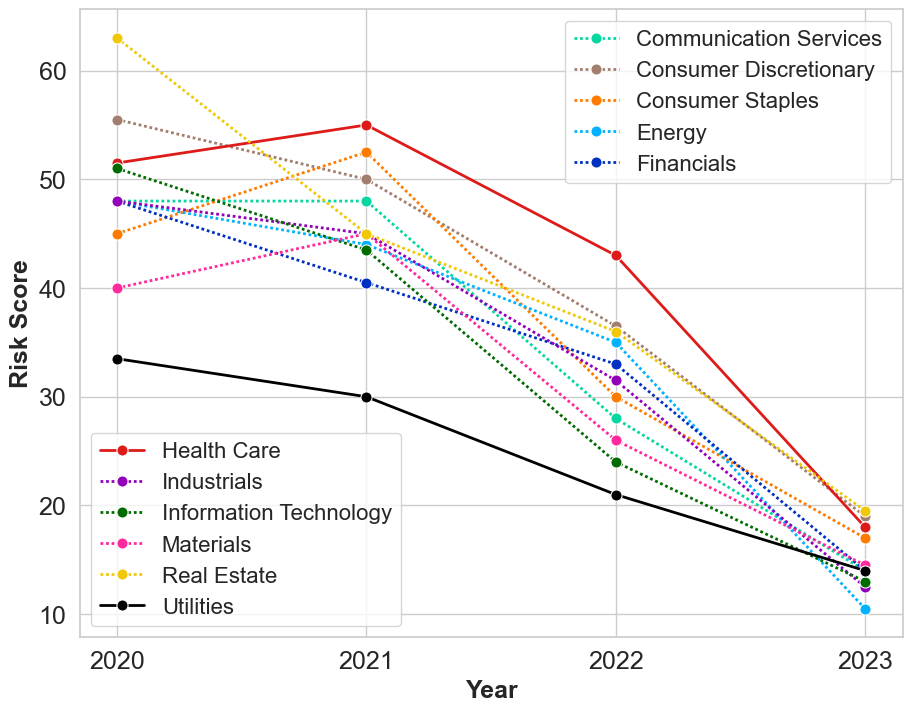

In [99]:
# 2. 右图
fig_2, axes_2 = plt.subplots(figsize=(9, 7))

color_map = {
    'Health Care': "#DD1C1A",  
    'Utilities': "#000000BF",  
    'Consumer Discretionary': "#A27E6F", 
    'Consumer Staples': "#FF7B00", 
    'Real Estate': "#F0C808", 
    'Information Technology': "#006C00", 
    'Communication Services': "#06D6A0", 
    'Energy': "#00B2FF", 
    'Financials': "#0030C2", 
    'Industrials': "#9200BA", 
    'Materials': "#FF299C"
}

linestyle_map = {
    'Health Care': '',  # 实线
    'Utilities': '',  # 虚线
    'Consumer Discretionary': (1, 1), 
    'Consumer Staples': (1, 1), 
    'Real Estate': (1, 1), 
    'Information Technology': (1, 1), 
    'Communication Services': (1, 1), 
    'Energy': (1, 1), 
    'Financials': (1, 1), 
    'Industrials': (1, 1), 
    'Materials': (1, 1)
}

sns.lineplot(
    data=avg_risk_by_sector,
    x='year',
    y='risk_score',
    hue='GICS_Sector',      # 根据行业区分【颜色】
    style='GICS_Sector',    # <--- 添加这一行！根据行业区分【线型】
    marker='o',
    markersize=8,
    linewidth=2,
    palette=color_map,
    alpha=1,
    zorder=10,
    dashes=linestyle_map,
    ax=axes_2
)

axes_2.set_xlabel('', fontsize=18, fontweight='bold')
axes_2.set_ylabel('', fontsize=18, fontweight='bold')
axes_2.set_xticks(avg_risk_by_sector['year'].unique())
axes_2.tick_params(axis='x', labelsize=18)
axes_2.tick_params(axis='y', labelsize=18)

handles, labels = axes_2.get_legend_handles_labels()

split = len(labels) // 2
handles1, labels1 = handles[:split], labels[:split]
handles2, labels2 = handles[split:], labels[split:]

leg1 = axes_2.legend(
    handles1, labels1,
    loc='upper right',               # legend 框内的锚点位置  # 相对轴坐标 (0,0) 左下 (1,1) 右上
    frameon=True,
    ncol=1,
    fontsize=16,
)
leg2 = axes_2.legend(
    handles2, labels2,
    loc='lower left',
    frameon=True,
    ncol=1,
    fontsize=16,
)
axes_2.add_artist(leg1)

fig_2.tight_layout()
axes_2.set_xlabel('Year', fontsize=18, weight='bold')
axes_2.set_ylabel('Risk Score', fontsize=18, weight='bold')
plt.savefig('./Figs/yearly_risk_trend_avg.pdf', dpi=600, bbox_inches='tight')
plt.show()